In [19]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import wilcoxon
import itertools
import sys
sys.path.insert(0, os.path.dirname(os.getcwd()))
import liset_tk.lists_sessions as lists_sessions
# Set style
sns.set_style("whitegrid")
# plt.rcParams.update({'font.size': 12})
plt.rcParams['svg.fonttype'] = 'none'
import dutta_test.utils as utils

In [12]:
# Load Data
results_path = os.path.join("spikes", "all_networks_metrics_dutta.csv")

if os.path.exists(results_path):
    df = pd.read_csv(results_path)
    print(f"Loaded {len(df)} rows from {results_path}")
    
    # Preprocessing
    # Rename ADAPT to Adapt for consistency
    if "ADAPT" in df.columns:
        df.rename(columns={"ADAPT": "Adapt"}, inplace=True)
        
    print("Columns:", df.columns.tolist())
    print("Threshold:", sorted(df["Threshold"].unique()))
    
    display(df.head())
else:
    print(f"File not found: {results_path}. Please run process_live_spikes.py first.")

Loaded 162 rows from spikes\all_networks_metrics_dutta.csv
Columns: ['Session', 'Channel', 'Threshold', 'TP', 'FP', 'FN', 'Precision', 'Recall', 'F1', 'Mean_Latency', 'Num_Spikes', 'Num_Ripples', 'Duration_min']
Threshold: [3.0, 4.0, 5.0, 6.0, 7.0, 8.0]


,Session,Channel,Threshold,TP,FP,FN,Precision,Recall,F1,Mean_Latency,Num_Spikes,Num_Ripples,Duration_min
0,2025-09-24_17-38-17,13,3.0,11,564,4,0.019130,0.733333,0.037288,35.321212,577,15,10.479720
1,2025-09-24_16-29-07,5,3.0,25,497,15,0.047893,0.625000,0.088968,9.848000,528,40,10.618442
2,2025-09-22_17-55-26,26,3.0,130,251,55,0.341207,0.702703,0.459364,16.261795,385,185,10.399793
3,2025-09-23_15-50-26,28,3.0,94,333,45,0.220141,0.676259,0.332155,11.527305,430,139,10.387618
4,2025-09-24_10-24-40,30,3.0,57,502,35,0.101968,0.619565,0.175115,16.625731,564,92,10.413202


In [13]:
hfo_sessions = lists_sessions.HFO_sessions
ripple_sessions = lists_sessions.Ripple_sessions

sessions_to_reject={
    # "2025-09-24_16-29-07", #R   # Nothing concrete to reject here
        "2025-09-24_17-38-17", # Barely any ripples (14 in total...)
        "2025-09-25_12-52-22", # Not a good session to detect ripples
        #  "2025-09-24_11-34-51",
        } #R 
# og_session_set={"2025-09-22_17-55-26", #R
# #                 "2025-09-23_15-50-26", #R
# #                 "2025-09-24_10-24-40", #R
# #                 "2025-09-24_14-22-55", #H
# #                 "2025-09-24_15-13-10", #H
# #                 "2025-09-25_16-41-14"} #R    
# }
sessions_to_reject.update(hfo_sessions)

    # df=df[df["Session"].isin(og_session_set)]

    # # New sessions:

    

df=df[~df["Session"].isin(sessions_to_reject)]
print(df["Session"].unique())
# df=df[~df["Session"].isin(ripple_sessions)]

['2025-09-24_16-29-07' '2025-09-22_17-55-26' '2025-09-23_15-50-26'
 '2025-09-24_10-24-40' '2025-09-23_16-17-52' '2025-09-25_11-21-53'
 '2025-09-24_11-34-51' '2025-09-25_16-41-14' '2025-09-22_17-42-27'
 'PV01ai32FPGA_250611_122326' 'PV01ai32FPGA_250611_115923'
 'Calbai32FPGA_251003_150055' 'Calbai32FPGA_251003_144832'
 'Calb_251211_105518' 'Calb_251210_122327' 'Calb_251209_160255'
 'Calb_251210_162849' 'Calb_251210_164150' 'Calb_251210_121141'
 'Calb_251211_110650' 'Calb_251211_104316' 'Calb_251210_115904'
 'Calb_251210_165332']


In [14]:
# Print summary
print("\n--- Summary by Network ---")
summary = df.groupby("Threshold")[["F1", "Precision", "Recall", "TP", "FP", "FN"]].median().round(3).sort_values(by="F1", ascending=False)
display(summary)


--- Summary by Network ---


,F1,Precision,Recall,TP,FP,FN
Threshold,,,,,,
7.0,0.633,0.709,0.575,63.0,23.0,47.0
6.0,0.613,0.610,0.656,70.0,40.0,37.0
8.0,0.600,0.781,0.457,50.0,13.0,58.0
5.0,0.570,0.506,0.715,79.0,87.0,30.0
4.0,0.490,0.351,0.750,86.0,172.0,29.0
3.0,0.329,0.208,0.719,81.0,376.0,30.0


In [15]:
print(summary.loc[summary["F1"].idxmax()])

F1            0.633
Precision     0.709
Recall        0.575
TP           63.000
FP           23.000
FN           47.000
Name: 7.0, dtype: float64


In [16]:
# Print summary
print("\n--- Summary by Session ---")
for threshold in df["Threshold"].unique():
    print(f"\nThreshold: {threshold}")
    summary = df[df["Threshold"]==threshold].groupby("Session")[["F1", "Precision", "Recall", "TP", "FP", "FN"]].mean().round(3).sort_values(by="F1", ascending=False)
    display(summary)


--- Summary by Session ---

Threshold: 3.0


,F1,Precision,Recall,TP,FP,FN
Session,,,,,,
Calbai32FPGA_251003_150055,0.489,0.359,0.763,142.0,253.0,44.0
2025-09-22_17-55-26,0.459,0.341,0.703,130.0,251.0,55.0
Calbai32FPGA_251003_144832,0.458,0.333,0.731,141.0,282.0,52.0
Calb_251209_160255,0.452,0.323,0.758,50.0,105.0,16.0
PV01ai32FPGA_250611_115923,0.392,0.270,0.719,151.0,409.0,59.0
2025-09-25_11-21-53,0.390,0.284,0.624,126.0,318.0,76.0
PV01ai32FPGA_250611_122326,0.388,0.258,0.775,131.0,376.0,38.0
Calb_251210_164150,0.369,0.240,0.797,94.0,297.0,24.0
2025-09-25_16-41-14,0.362,0.242,0.715,103.0,322.0,41.0



Threshold: 4.0


,F1,Precision,Recall,TP,FP,FN
Session,,,,,,
Calbai32FPGA_251003_150055,0.659,0.563,0.796,148.0,115.0,38.0
2025-09-22_17-55-26,0.656,0.588,0.741,137.0,96.0,48.0
Calbai32FPGA_251003_144832,0.642,0.550,0.772,149.0,122.0,44.0
Calb_251209_160255,0.592,0.485,0.758,50.0,53.0,16.0
PV01ai32FPGA_250611_122326,0.558,0.460,0.710,120.0,141.0,49.0
PV01ai32FPGA_250611_115923,0.540,0.488,0.605,127.0,133.0,83.0
2025-09-23_15-50-26,0.528,0.413,0.734,102.0,145.0,37.0
2025-09-25_11-21-53,0.519,0.432,0.649,131.0,172.0,71.0
Calb_251210_164150,0.511,0.378,0.788,93.0,153.0,25.0



Threshold: 5.0


...

,F1,Precision,Recall,TP,FP,FN
Session,,,,,,
Calbai32FPGA_251003_144832,0.734,0.855,0.642,124.0,21.0,69.0
Calbai32FPGA_251003_150055,0.727,0.872,0.624,116.0,17.0,70.0
2025-09-23_15-50-26,0.726,0.748,0.705,98.0,33.0,41.0
2025-09-22_17-55-26,0.718,0.882,0.605,112.0,15.0,73.0
Calb_251210_164150,0.689,0.692,0.686,81.0,36.0,37.0
Calb_251209_160255,0.683,0.759,0.621,41.0,13.0,25.0
Calb_251210_165332,0.681,0.660,0.703,64.0,33.0,27.0
PV01ai32FPGA_250611_122326,0.654,0.880,0.521,88.0,12.0,81.0
Calb_251210_162849,0.651,0.596,0.717,81.0,55.0,32.0



Threshold: 7.0


,F1,Precision,Recall,TP,FP,FN
Session,,,,,,
Calb_251210_165332,0.723,0.800,0.659,60.0,15.0,31.0
2025-09-23_15-50-26,0.710,0.821,0.626,87.0,19.0,52.0
Calbai32FPGA_251003_150055,0.703,0.963,0.554,103.0,4.0,83.0
2025-09-22_17-55-26,0.699,0.953,0.551,102.0,5.0,83.0
Calb_251211_110650,0.694,0.658,0.735,50.0,26.0,18.0
Calbai32FPGA_251003_144832,0.684,0.921,0.544,105.0,9.0,88.0
Calb_251210_164150,0.679,0.780,0.602,71.0,20.0,47.0
Calb_251210_162849,0.676,0.709,0.646,73.0,30.0,40.0
Calb_251210_122327,0.656,0.652,0.659,60.0,32.0,31.0



Threshold: 8.0


,F1,Precision,Recall,TP,FP,FN
Session,,,,,,
Calb_251210_165332,0.712,0.945,0.571,52.0,3.0,39.0
Calb_251210_164150,0.684,0.903,0.551,65.0,7.0,53.0
Calb_251211_110650,0.661,0.755,0.588,40.0,13.0,28.0
2025-09-23_15-50-26,0.658,0.860,0.532,74.0,12.0,65.0
Calb_251210_122327,0.645,0.781,0.549,50.0,14.0,41.0
Calb_251209_160255,0.640,0.941,0.485,32.0,2.0,34.0
Calb_251210_162849,0.639,0.782,0.540,61.0,17.0,52.0
Calb_251210_121141,0.630,0.690,0.580,40.0,18.0,29.0
Calb_251210_115904,0.621,0.681,0.571,32.0,15.0,24.0


In [17]:
def barplot_annotate_brackets(num1, num2, data, center, height, ax, yerr=None, dh=.05, barh=.05, fs=None, maxasterix=None):
    """ 
    Annotate barplot with p-values. 
    Adapted from the provided script.
    """
    if type(data) is str:
        text = data
    else:
        if data > 0.05:
          return
        text = ''
        p = .05
        while data < p:
            text += '*'
            p /= 10.
            if maxasterix and len(text) == maxasterix:
                break
        if len(text) == 0:
            text = 'n. s.'

    lx, ly = center[num1], height[num1]
    rx, ry = center[num2], height[num2]

    if yerr:
        ly += yerr[num1]
        ry += yerr[num2]

    ax_y0, ax_y1 = plt.gca().get_ylim()
    dh *= (ax_y1 - ax_y0)
    barh *= (ax_y1 - ax_y0)

    y = max(ly, ry) + dh

    barx = [lx, lx, rx, rx]
    bary = [y, y+barh, y+barh, y]
    mid = ((lx+rx)/2, y+barh)

    ax.plot(barx, bary, c='black')

    kwargs = dict(ha='center', va='bottom')
    if fs is not None:
        kwargs['fontsize'] = fs

    ax.text(*mid, text, **kwargs)

C:\Users\NCN\AppData\Local\Temp\ipykernel_38620\3875192192.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Threshold", y=metric, data=plot_df, ax=ax, palette="viridis", width=0.8, inner="quart", cut=0, order=adapt_values)


N=23 matched samples for statistics.
3.0 vs 4.0: p=0.0000 True
3.0 vs 5.0: p=0.0000 True
3.0 vs 6.0: p=0.0000 True
3.0 vs 7.0: p=0.0000 True
3.0 vs 8.0: p=0.0000 True
4.0 vs 5.0: p=0.0000 True
4.0 vs 6.0: p=0.0000 True
4.0 vs 7.0: p=0.0001 True
4.0 vs 8.0: p=0.0207 True
5.0 vs 6.0: p=0.0243 True
5.0 vs 7.0: p=0.2095 False
5.0 vs 8.0: p=1.0000 False
6.0 vs 7.0: p=1.0000 False
6.0 vs 8.0: p=0.1107 False
7.0 vs 8.0: p=0.0004 True


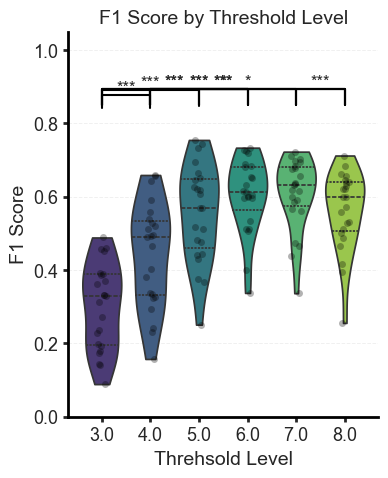

In [34]:
from snnTorch.generalization_madrid.utils import holm_bonferroni

# Define shared color palette for consistency across plots
# Get viridis colors based on number of thresholds (will be determined dynamically)
def get_threshold_colors(adapt_values):
    """Get consistent viridis colors for thresholds."""
    return sns.color_palette("viridis", len(adapt_values))

def plot_f1_boxplot_by_adapt(df, metric="F1", aggregate_by_network=False,figsize=(5,6)):
    # Define specific order
    # desired_order = [0, 120, 20, 2]
    # # Filter to only include values present in the dataframe
    # adapt_values = [a for a in desired_order if a in df["Threshold"].unique()]
    adapt_values = sorted(df["Threshold"].unique())
    # Data preparation
    if aggregate_by_network:
        # Average over sessions/channels for each network
        plot_df = df.groupby(["Network", "Threshold"])[metric].mean().reset_index()
        title_suffix = " (Averaged by Network)"
        print(f"Aggregated by network. N={len(plot_df['Network'].unique())} networks.")
    else:
        plot_df = df
        title_suffix = ""

    fig, ax = plt.subplots(figsize=figsize)
    
    # Boxplot
    # sns.boxplot(x="Threshold", y=metric, data=plot_df, ax=ax, palette="viridis", width=0.5, showfliers=False, order=adapt_values)
    sns.violinplot(x="Threshold", y=metric, data=plot_df, ax=ax, palette="viridis", width=0.8, inner="quart", cut=0, order=adapt_values)
    sns.stripplot(x="Threshold", y=metric, data=plot_df, ax=ax, color="black", alpha=0.3, jitter=True, order=adapt_values)
    
    # Statistical annotation (Wilcoxon)
    if aggregate_by_network:
        pivot_cols = ["Network"]
    else:
        pivot_cols = ["Session", "Channel",]
        
    pivot = plot_df.pivot_table(index=pivot_cols, columns="Threshold", values=metric)
    pivot = pivot.dropna()
    print(f"N={len(pivot)} matched samples for statistics.")
    p_values=[]
    pairs=[]
    if len(pivot) > 0:
        centers = range(len(adapt_values))
        # Calculate max height for annotations
        max_val = plot_df[metric].max()
        
        combinations = list(itertools.combinations(range(len(adapt_values)), 2))
        for idx, (i, j) in enumerate(combinations):
            a1 = adapt_values[i]
            a2 = adapt_values[j]
            
            v1 = pivot[a1].values
            v2 = pivot[a2].values
            
            # Check if we have enough samples for Wilcoxon
            if len(v1) >= 3:
                stat, p = wilcoxon(v1, v2)
                p_values.append(p)
                pairs.append((a1, a2))

                
                # Stacking logic for brackets
                # h = max_val + 0.05 * (1 + idx) * (max_val * 0.1)
                # print(f"{a1} vs {a2}: p={p:.4f}")
                # barplot_annotate_brackets(i, j, p, centers, [h]*len(centers), ax)
            else:
                print(f"Skipping stats for {a1} vs {a2}: N={len(v1)} too small")
            
        corrected_significant, adjusted_pvals=utils.holm_bonferroni(p_values,alpha=0.05)
        for p,sig,(b1,b2) in zip(adjusted_pvals,corrected_significant,pairs):        
                print(f"{b1} vs {b2}: p={p:.4f} {sig}")          
                barplot_annotate_brackets(adapt_values.index(b1), adapt_values.index(b2), p, centers, [max_val+0.05]*len(centers), ax, fs=12, maxasterix=3)   

    ax.grid(True, axis='y', linestyle='--',linewidth=0.7,alpha=0.3)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)   
   
    ax.set_title(f"{metric} Score by Threshold Level{title_suffix}",fontsize=14)
    ax.set_ylim(0, 1.05) # Adjust to fit brackets
    ax.set_ylabel(f"{metric} Score",fontsize=14)
    ax.set_xlabel("Threhsold Level",fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=13, bottom=True, left=True,width=2.0)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    ax.spines['bottom'].set_color('black')
    ax.spines['left'].set_color('black')

    plt.show()
    return fig,ax
if 'df' in locals():
   fig,ax = plot_f1_boxplot_by_adapt(df, "F1", aggregate_by_network=False,figsize=(4,5))

Precision    Recall
Threshold                          
3.0       0.25   0.115338  0.663818
          0.50   0.208211  0.719048
          0.75   0.264013  0.779533
4.0       0.25   0.217891  0.667391
          0.50   0.350711  0.750000

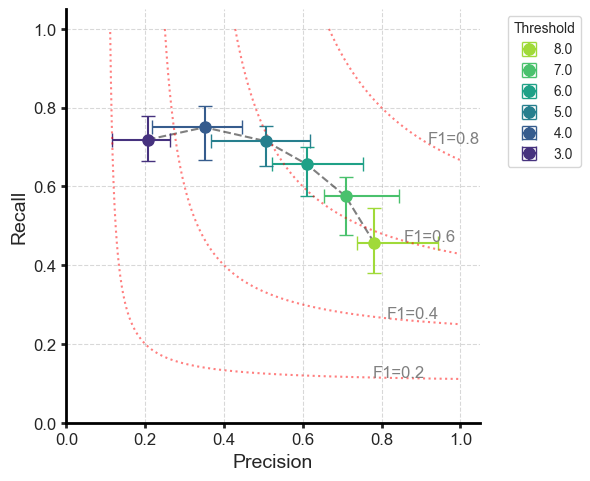

In [36]:
def plot_precision_recall_curve(df, thresholds_to_include=None):
    # Filter for specific buffer size if needed, e.g., buffer=6

    mask=(df["Threshold"].isin(thresholds_to_include)) 
    df_subset = df[mask].copy()
    
    # Calculate median (50%), 25%, and 75% quantiles
    summary = df_subset.groupby("Threshold")[["Precision", "Recall"]].quantile([0.25, 0.5, 0.75]) # one row per threshold per quantile
    display(summary.head())
    # Sort index appropriately for plotting logic
    # Unstack to get columns like (Precision, 0.5), (Precision, 0.25) ...
    summary = summary.unstack(level=1) # create multi-index columns # Metric, Quantile
    # display(summary.head()  )
    # Extract Medians as the central point
    means = summary.xs(0.5, axis=1, level=1).sort_index(ascending=False) # Extract median values (Threshold, Metric)
    # display(means.head())

    # Calculate IQR errors:
    # lower_err = median - Q1
    # upper_err = Q3 - median
    q1 = summary.xs(0.25, axis=1, level=1).sort_index(ascending=False) # Extract Q1 values (Threshold, Metric)
    q3 = summary.xs(0.75, axis=1, level=1).sort_index(ascending=False) # Extract Q3 values (Threshold, Metric)
    
    # Define errors for errorbar plot (shape: 2xN for each point [lower, upper])
    # Precision Errors
    prec_err_lower = means["Precision"] - q1["Precision"]
    prec_err_upper = q3["Precision"] - means["Precision"]
    
    # Recall Errors
    rec_err_lower = means["Recall"] - q1["Recall"]
    rec_err_upper = q3["Recall"] - means["Recall"]
    
    thresholds = means.index.values

    fig,ax=plt.subplots(figsize=(6,6))
    
    # Plot the line connecting the medians
    ax.plot(means["Precision"], means["Recall"], 'k--', alpha=0.5)
    
    # Plot points with IQR error bars
    sorted_thresholds = sorted(thresholds)
    # Use same viridis colors as cell 8
    colors = get_threshold_colors(sorted_thresholds)
    color_map = {th: col for th, col in zip(sorted_thresholds, colors)}
    
    for i, th in enumerate(thresholds):
        # Prepare error arrays (needs to be sequence of shape (2, 1) or scalar if symmetric, but here asymmetric)
        xerr = [[prec_err_lower[th]], [prec_err_upper[th]]]
        yerr = [[rec_err_lower[th]], [rec_err_upper[th]]]
        
        ax.errorbar(means.loc[th, "Precision"], means.loc[th, "Recall"], 
                     xerr=xerr, 
                     yerr=yerr, 
                     fmt='o', color=color_map[th], 
                     capsize=5, label=f'{th}', markersize=8)

    # Add F1 isolines for reference
    f1_scores = [0.2, 0.4, 0.6, 0.8]
    x = np.linspace(0, 1, 10000)
    for f1 in f1_scores:
        y = (f1 * x) / (2 * x - f1)
        valid = (y > 0) & (y < 1)
        ax.plot(x[valid], y[valid], 'r:', linewidth=1.5,alpha=0.5)
        if any(valid):
            ax.text(x[valid][int(len(x[valid])*0.75)], y[valid][int(len(y[valid])*0.75)], f"F1={f1}", color='gray', fontsize=12)

    ax.set_xlabel("Precision",fontsize=14)
    ax.set_ylabel("Recall",fontsize=14)
    ax.set_xlim(0,1.05)
    ax.set_ylim(0,1.05)
    
    # Set Aspect Ratio to be Equal
    ax.set_aspect('equal', adjustable='box')
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines[['bottom','left']].set_linewidth(2)
    ax.spines[['bottom','left']].set_color('black')
    ax.tick_params(axis='both', which='major', labelsize=12, width=2,bottom=True, left=True)
    ax.grid(True, which='major', axis='both', linestyle='--', color='gray', alpha=0.3)
    
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left', title="Threshold")
    plt.tight_layout()
    plt.show()  
    return fig,ax
fig,ax = plot_precision_recall_curve(df, thresholds_to_include=sorted(df["Threshold"].unique()))

C:\Users\NCN\AppData\Local\Temp\ipykernel_22884\3604372674.py:23: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x="Threshold", y=metric, data=plot_df, ax=ax, palette=colors, inner="quartile", cut=0, order=adapt_values)
C:\Users\NCN\AppData\Local\Temp\ipykernel_22884\3604372674.py:23: UserWarning: 
The palette list has fewer values (4) than needed (6) and will cycle, which may produce an uninterpretable plot.
  sns.violinplot(x="Threshold", y=metric, data=plot_df, ax=ax, palette=colors, inner="quartile", cut=0, order=adapt_values)


3.0 vs 4.0: p=0.0000
3.0 vs 5.0: p=0.0000
3.0 vs 6.0: p=0.0000
3.0 vs 7.0: p=0.0000
3.0 vs 8.0: p=0.0000
4.0 vs 5.0: p=0.0000
4.0 vs 6.0: p=0.0000
4.0 vs 7.0: p=0.0000
4.0 vs 8.0: p=0.0035
5.0 vs 6.0: p=0.0049
5.0 vs 7.0: p=0.0698
5.0 vs 8.0: p=0.8462
6.0 vs 7.0: p=0.8462
6.0 vs 8.0: p=0.0277
7.0 vs 8.0: p=0.0001


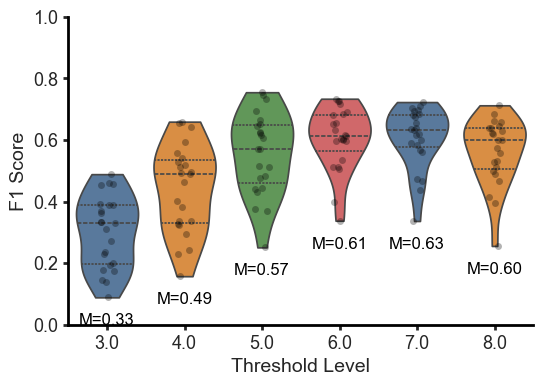

In [9]:
def plot_f1_violin_by_adapt(df, metric="F1", aggregate_by_network=False):
    # Define specific order
    # desired_order = [0, 120, 20, 2]
    # Filter to only include values present in the dataframe
    # adapt_values = [a for a in desired_order if a in df["Adapt"].unique()]
    adapt_values = sorted(df["Threshold"].unique())

    # Data preparation
    if aggregate_by_network:
        # Average over sessions/channels for each network
        plot_df = df.groupby(["Network", "Threshold"])[metric].mean().reset_index()
        title_suffix = " (Averaged by Network)"
        print(f"Aggregated by network. N={len(plot_df['Network'].unique())} networks.")
    else:
        plot_df = df
        title_suffix = ""

    fig, ax = plt.subplots(figsize=(6, 4))
    
    colors=["#4E79A7", "#F28E2B", "#59A14F", "#E15759"]

    # Violin plot
    sns.violinplot(x="Threshold", y=metric, data=plot_df, ax=ax, palette=colors, inner="quartile", cut=0, order=adapt_values)
    # Overlay points
    sns.stripplot(x="Threshold", y=metric, data=plot_df, ax=ax, color="black", alpha=0.3, jitter=True, order=adapt_values)
    
    # Statistical annotation (Wilcoxon)
    if aggregate_by_network:
        pivot_cols = ["Network"]
    else:
        pivot_cols = ["Session", "Channel",]
        
    pivot = plot_df.pivot_table(index=pivot_cols, columns="Threshold", values=metric)
    # display(pivot.head())
    pivot = pivot.dropna()

    # Annotate medians and N
    medians = plot_df.groupby('Threshold')[metric].median()
    counts = plot_df.groupby('Threshold')[metric].count()
    mins=plot_df.groupby('Threshold')[metric].min() 
        
    for i, adapt in enumerate(adapt_values):
        if adapt in medians:
            val = medians[adapt]
            min_val = mins[adapt]
            ax.text(i, min_val- 0.1, f'M={val:.2f}',  
            ha='center', va='bottom', fontsize=12, color='black')

    if len(pivot) > 0:
        centers = range(len(adapt_values))
        max_val = plot_df[metric].max()
        
        combinations = list(itertools.combinations(range(len(adapt_values)), 2))
        for idx, (i, j) in enumerate(combinations):
            a1 = adapt_values[i]
            a2 = adapt_values[j]
            
            v1 = pivot[a1].values
            v2 = pivot[a2].values
            
            # Check if we have enough samples for Wilcoxon
            if len(v1) >= 3: 
                stat, p = wilcoxon(v1, v2)
                
                # Stacking logic for brackets
                h = max_val + 0.05 * (1 + idx) * (max_val * 0.1)
                
                print(f"{a1} vs {a2}: p={p:.4f}")
                # barplot_annotate_brackets(i, j, p, centers, [h]*len(centers), ax)
            else:
                print(f"Skipping stats for {a1} vs {a2}: N={len(v1)} too small")
                
    # ax.set_title(f"{metric} Distribution by Adaptation Level{title_suffix}")
    ax.set_ylim(0,1) 

    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines[['bottom','left']].set_linewidth(1.3)
    ax.spines[['bottom','left']].set_color('black')
    # ax.set_xticklabels(["Fixed","60", "10", "1"])
    ax.tick_params(axis='both', which='major', labelsize=13, bottom=True, left=True,width=2)
    ax.tick_params(axis='x', rotation=0)

    ax.set_ylabel(f"{metric} Score",fontsize=14)
    ax.set_xlabel("Threshold Level",fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=13)
    ax.spines['bottom'].set_linewidth(2)
    ax.spines['left'].set_linewidth(2)
    plt.show()
    return fig,ax

if 'df' in locals():
    fig,ax=plot_f1_violin_by_adapt(df, "F1", aggregate_by_network=False)
    os.makedirs("figures", exist_ok=True)
    # fig.savefig("figures/f1_violin_by_adapt.svg", dpi=300, bbox_inches='tight')
    # fig.savefig("figures/f1_violin_by_adapt.png",dpi=300)

C:\Users\NCN\AppData\Local\Temp\ipykernel_22884\1127962853.py:28: RuntimeWarning: divide by zero encountered in divide
  y = (f1 * x) / (2 * x - f1)


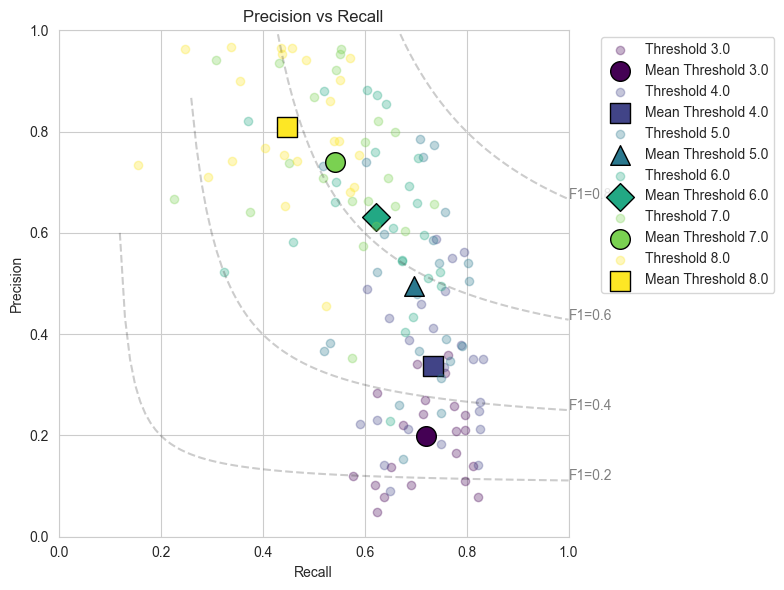

In [10]:
def plot_precision_recall(df):
    plt.figure(figsize=(8, 6))
    
    #  # Define specific order
    # desired_order = [0, 120, 20, 2]
    # # Filter to only include values present in the dataframe
    # adapt_values = [a for a in desired_order if a in df["Adapt"].unique()]
    adapt_values = sorted(df["Threshold"].unique())
    
    markers = ['o', 's', '^', 'D']
    colors = plt.cm.viridis(np.linspace(0, 1, len(adapt_values)))
    
    for i, adapt in enumerate(adapt_values):
        subset = df[df["Threshold"] == adapt]
        
        # Mean point
        mean_p = subset["Precision"].mean()
        mean_r = subset["Recall"].mean()
        
        plt.scatter(subset["Recall"], subset["Precision"], label=f"Threshold {adapt}", alpha=0.3, color=colors[i])
        plt.scatter(mean_r, mean_p, s=200, edgecolor='black', marker=markers[i%len(markers)], 
                    label=f"Mean Threshold {adapt}", color=colors[i])
        
    # F1 isolines
    f1_scores = [0.2, 0.4, 0.6, 0.8]
    x = np.linspace(0.01, 1, 100)
    for f1 in f1_scores:
        y = (f1 * x) / (2 * x - f1)
        # Filter valid y
        valid = (y >= 0) & (y <= 1)
        plt.plot(x[valid], y[valid], 'k--', alpha=0.2)
        if any(valid):
            plt.text(x[valid][-1], y[valid][-1], f"F1={f1}", color='gray')
        
    plt.xlabel("Recall")
    plt.ylabel("Precision")
    plt.title("Precision vs Recall")
    plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
    plt.xlim(0, 1)
    plt.ylim(0, 1)
    plt.grid(True)
    plt.tight_layout()
    plt.show()

if 'df' in locals():
    plot_precision_recall(df)

,Session,Channel,Threshold,Metric,Value
0,2025-09-22_17-55-26,26,5.0,Precision,0.784431
1,2025-09-25_11-21-53,21,5.0,Precision,0.597222
2,2025-09-22_17-42-27,24,5.0,Precision,0.381579
3,2025-09-24_11-34-51,30,5.0,Precision,0.366337
4,2025-09-23_16-17-52,24,5.0,Precision,0.260870


C:\Users\NCN\AppData\Local\Temp\ipykernel_22884\258087946.py:30: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(x='Metric', y='Value', data=melted, ax=ax, palette='viridis', inner='quartile', cut=0, order=order,alpha=.8,linewidth=2)


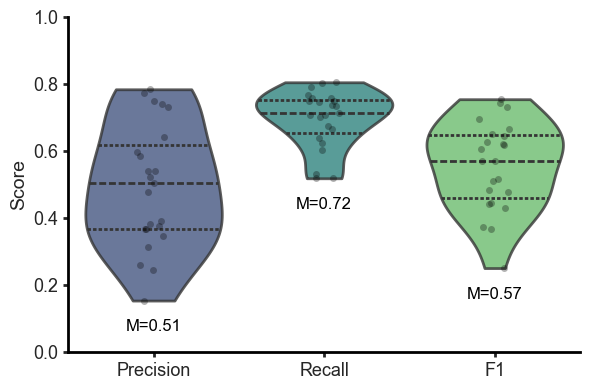

In [11]:
# Plot Precision, Recall and F1 for a single Adaptation level in the same figure
def plot_metrics_single_adapt(df, adapt=20, aggregate_by_network=False, metrics=("Precision", "Recall", "F1")):
    """Plot the distributions of multiple metrics for a single `adapt` value in one plot."""
    # Ensure adapt exists in the dataframe
    if adapt not in df["Threshold"].unique():
        print(f"Adapt {adapt} not present in dataframe. Available: {sorted(df['Threshold'].unique())}")
        return

    # Prepare data for the requested adapt
    if aggregate_by_network:
        agg_cols = ['Network', 'Adapt']
        plot_df = df.groupby(agg_cols)[list(metrics)].mean().reset_index()
        title_suffix = ' (Averaged by Network)'
    else:
        plot_df = df.copy()
        title_suffix = ''

    plot_df = plot_df[plot_df['Threshold'] == adapt]
    if len(plot_df) == 0:
        print(f'No rows for Threshold {adapt} after filtering.')
        return

    # Melt metrics into long form for plotting
    id_vars = [c for c in ['Session', 'Channel', 'Threshold'] if c in plot_df.columns]
    melted = plot_df.melt(id_vars=id_vars, value_vars=list(metrics), var_name='Metric', value_name='Value')
    display(melted.head())
    # Plot
    fig, ax = plt.subplots(figsize=(6, 4))
    order = list(metrics)
    sns.violinplot(x='Metric', y='Value', data=melted, ax=ax, palette='viridis', inner='quartile', cut=0, order=order,alpha=.8,linewidth=2)
    sns.stripplot(x='Metric', y='Value', data=melted, ax=ax, color='k', alpha=0.3, jitter=True, order=order)

    # Annotate medians and N
    medians = melted.groupby('Metric')['Value'].median()
    counts = melted.groupby('Metric')['Value'].count()
    mins=melted.groupby('Metric')['Value'].min() 
    
    for i, metric in enumerate(order):
        if metric in medians:
            val = medians[metric]
            min_val = mins[metric]
            ax.text(i, min_val- 0.1, f'M={val:.2f}',  
            ha='center', va='bottom', fontsize=12, color='black')

    ax.set_ylim(0, 1)
    # ax.set_title(f'Performance Metrics', fontsize=14)
    ax.set_ylabel('Score', fontsize=14)
    ax.set_xlabel('')
    # ax.set_xlabel('Metric', fontsize=14)
    # ax.grid(True, axis='y', linestyle='--', linewidth=0.6, alpha=0.4)
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines[['bottom','left']].set_linewidth(2)
    ax.spines[['bottom','left']].set_color('black')

    ax.tick_params(axis='both', which='major', labelsize=13, bottom=True, left=True,width=2.0)
    ax.tick_params(axis='x', rotation=0)
    # ax.set_yticks(np.arange(0.3, 1.1, 0.1))
    plt.tight_layout()
    plt.show()
    return fig, ax

if 'df' in locals():
    fig,ax=plot_metrics_single_adapt(df, adapt=5.0, aggregate_by_network=False)
    # plot_f1_violin_by_adapt(df, "F1", aggregate_by_network=False)
    # fig.savefig("figures/metrics_single_adapt.svg", format="svg")
    # fig.savefig("figures/metrics_single_adapt.png", format="png", dpi=300)

Optimizing metrics over: ['Threshold']
Original rows: 138, Optimized rows: 23

--- Optimized Performance Summary (Best Threshold Per Session) ---


,F1,Precision,Recall
count,23.000,23.000,23.000
mean,0.641,0.663,0.628
std,0.082,0.109,0.079
min,0.430,0.366,0.459
25%,0.612,0.607,0.578
50%,0.639,0.662,0.642
75%,0.694,0.735,0.683
max,0.755,0.855,0.758


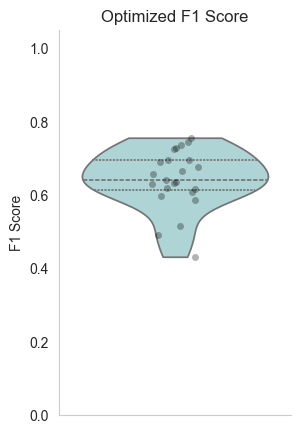

In [12]:
# Compute the performance considering the best configuration per session
def compute_best_performance(df, metric="F1", optimize=["Threshold", "Model", "Network"], average_over=["Channel"]):
    """
    Computes the best performance for each session by selecting the configuration (Threshold, Model, etc.)
    that maximizes the given metric.
    """
    # 1. Validate columns
    optimize = [col for col in optimize if col in df.columns]
    
    if not optimize:
        print("No columns to optimize found.")
        return df

    print(f"Optimizing metrics over: {optimize}")

    # 2. Group by Session and Optimization parameters to find mean performance (e.g. across channels)
    group_cols = ["Session"] + optimize
    
    # Calculate the mean score of the target metric for each configuration
    performance_per_config = df.groupby(group_cols)[metric].mean().reset_index()

    # 3. select the best configuration for each session
    best_configs = performance_per_config.sort_values(by=[metric], ascending=False).drop_duplicates(subset=["Session"])

    # 4. Merge back to get the full rows (metrics per channel) for the best configs
    best_performance_df = df.merge(best_configs[group_cols], on=group_cols, how="inner")
    
    # Print stats
    print(f"Original rows: {len(df)}, Optimized rows: {len(best_performance_df)}")
    
    return best_performance_df

if 'df' in locals():
    # Run optimization (Optimizing Threshold)
    df_opt = compute_best_performance(df, optimize=["Threshold"])
    
    # Show Summary
    print("\n--- Optimized Performance Summary (Best Threshold Per Session) ---")
    display(df_opt[["F1", "Precision", "Recall"]].describe().round(3))
    
    # Visualization
    fig, ax = plt.subplots(figsize=(3, 5))
    sns.violinplot(y="F1", data=df_opt, color="#a8dadc", inner="quartile", ax=ax, cut=0)
    sns.stripplot(y="F1", data=df_opt, color="black", alpha=0.3, ax=ax)
    ax.set_ylim(0, 1.05)
    ax.set_ylabel("F1 Score")
    ax.set_title("Optimized F1 Score")
    ax.grid(False)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    plt.show()